Dataset loaded successfully!
       date   quarter  department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1      sweing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing   Thursday     1                   0.75   
2  1/1/2015  Quarter1      sweing  Thursday    11                   0.80   
3  1/1/2015  Quarter1      sweing  Thursday    12                   0.80   
4  1/1/2015  Quarter1      sweing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  
0                   0           59.0             0.940725  
1              

c:\Users\salek\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\salek\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


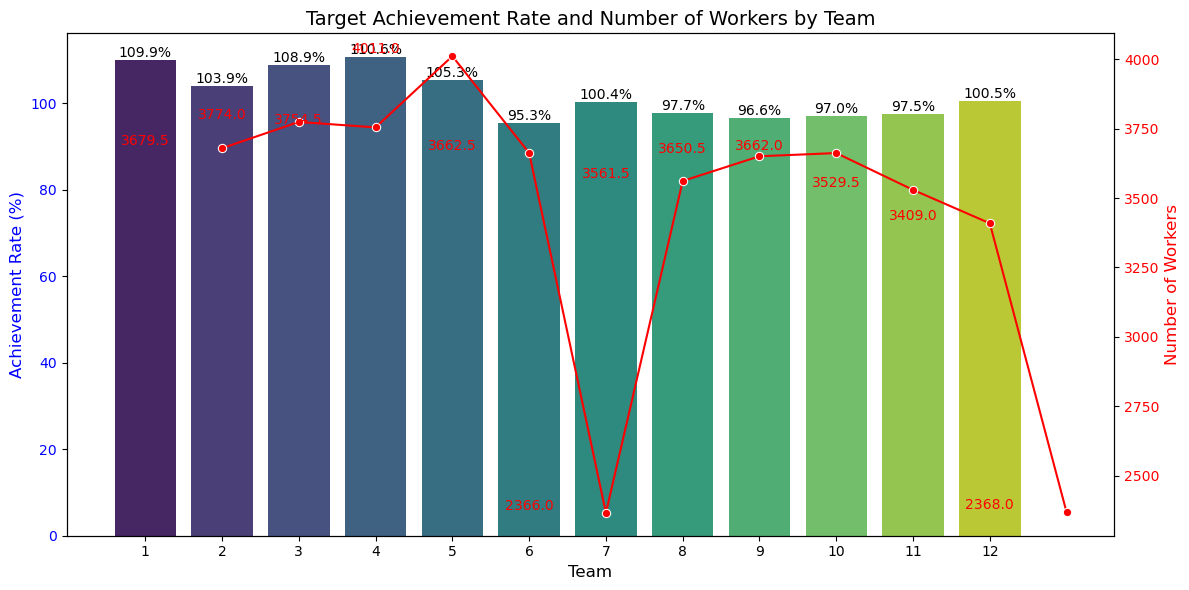


Running Tests...
Column names test passed.
Data types test passed.
Metrics test passed.
All tests passed successfully!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset
try:
    
    file_path = r"C:\Users\salek\garments_worker_productivity.csv"
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    # Display the first few rows of the dataset
    print(df.head())  
except FileNotFoundError:
    print("Dataset file not found. Ensure the file path is correct and the file exists.")
    raise
except Exception as e:
    print(f"An error occurred: {e}")
    raise

# Dataset Information
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Replace missing or invalid values in critical columns (if any)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Calculate Achievement Rate
df['achievement_rate'] = (df['actual_productivity'] / df['targeted_productivity']) * 100
df['achievement_rate'].replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['achievement_rate'], inplace=True)

# Group and Calculate Metrics
team_metrics = df.groupby('team').agg({
    'achievement_rate': 'mean',
    'no_of_workers': 'sum'
}).reset_index()

print("\nTeam Metrics:")
print(team_metrics)

# Visualization - Achievement Rate and Number of Workers
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for achievement rate
bar_plot = sns.barplot(
    x='team', y='achievement_rate', data=team_metrics, palette='viridis', ax=ax1
)
ax1.set_ylabel('Achievement Rate (%)', fontsize=12, color='b')
ax1.set_title('Target Achievement Rate and Number of Workers by Team', fontsize=14)
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlabel('Team', fontsize=12)

# Annotate the bars
for bar in bar_plot.containers[0]:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', 
        ha='center', va='bottom', fontsize=10, color='black'
    )

# Line plot for number of workers on a secondary axis
ax2 = ax1.twinx()
line_plot = sns.lineplot(
    x='team', y='no_of_workers', data=team_metrics, color='red', marker='o', ax=ax2
)
ax2.set_ylabel('Number of Workers', fontsize=12, color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Annotate the line plot
for i, row in team_metrics.iterrows():
    ax2.text(
        x=i, y=row['no_of_workers'] + 1, s=f"{row['no_of_workers']}", 
        ha='center', va='bottom', fontsize=10, color='red'
    )

# Adjust layout and show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Test Functions
def test_column_names():
    required_columns = ['date', 'team', 'targeted_productivity', 'actual_productivity', 'no_of_workers']
    for col in required_columns:
        assert col in df.columns, f"Missing column: {col}"
    print("Column names test passed.")

def test_data_types():
    assert pd.api.types.is_numeric_dtype(df['actual_productivity']), "Column 'actual_productivity' is not numeric."
    assert pd.api.types.is_numeric_dtype(df['targeted_productivity']), "Column 'targeted_productivity' is not numeric."
    print("Data types test passed.")

def test_metrics():
    assert 'achievement_rate' in df.columns, "Achievement rate not calculated."
    assert not df['achievement_rate'].isnull().any(), "Achievement rate contains NaN values."
    print("Metrics test passed.")

# Run tests
print("\nRunning Tests...")
test_column_names()
test_data_types()
test_metrics()
print("All tests passed successfully!")
